In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [33]:
data = pd.read_csv('bodyfat.csv')

In [34]:
df = data.copy()

In [35]:
df.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns


In [40]:
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

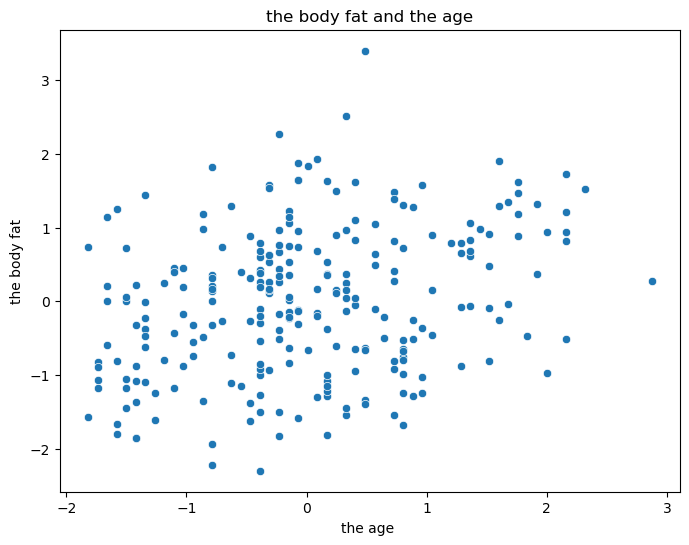

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Age',y='BodyFat')
plt.xlabel('the age ')
plt.ylabel('the body fat')
plt.title('the body fat and the age')
plt.show()

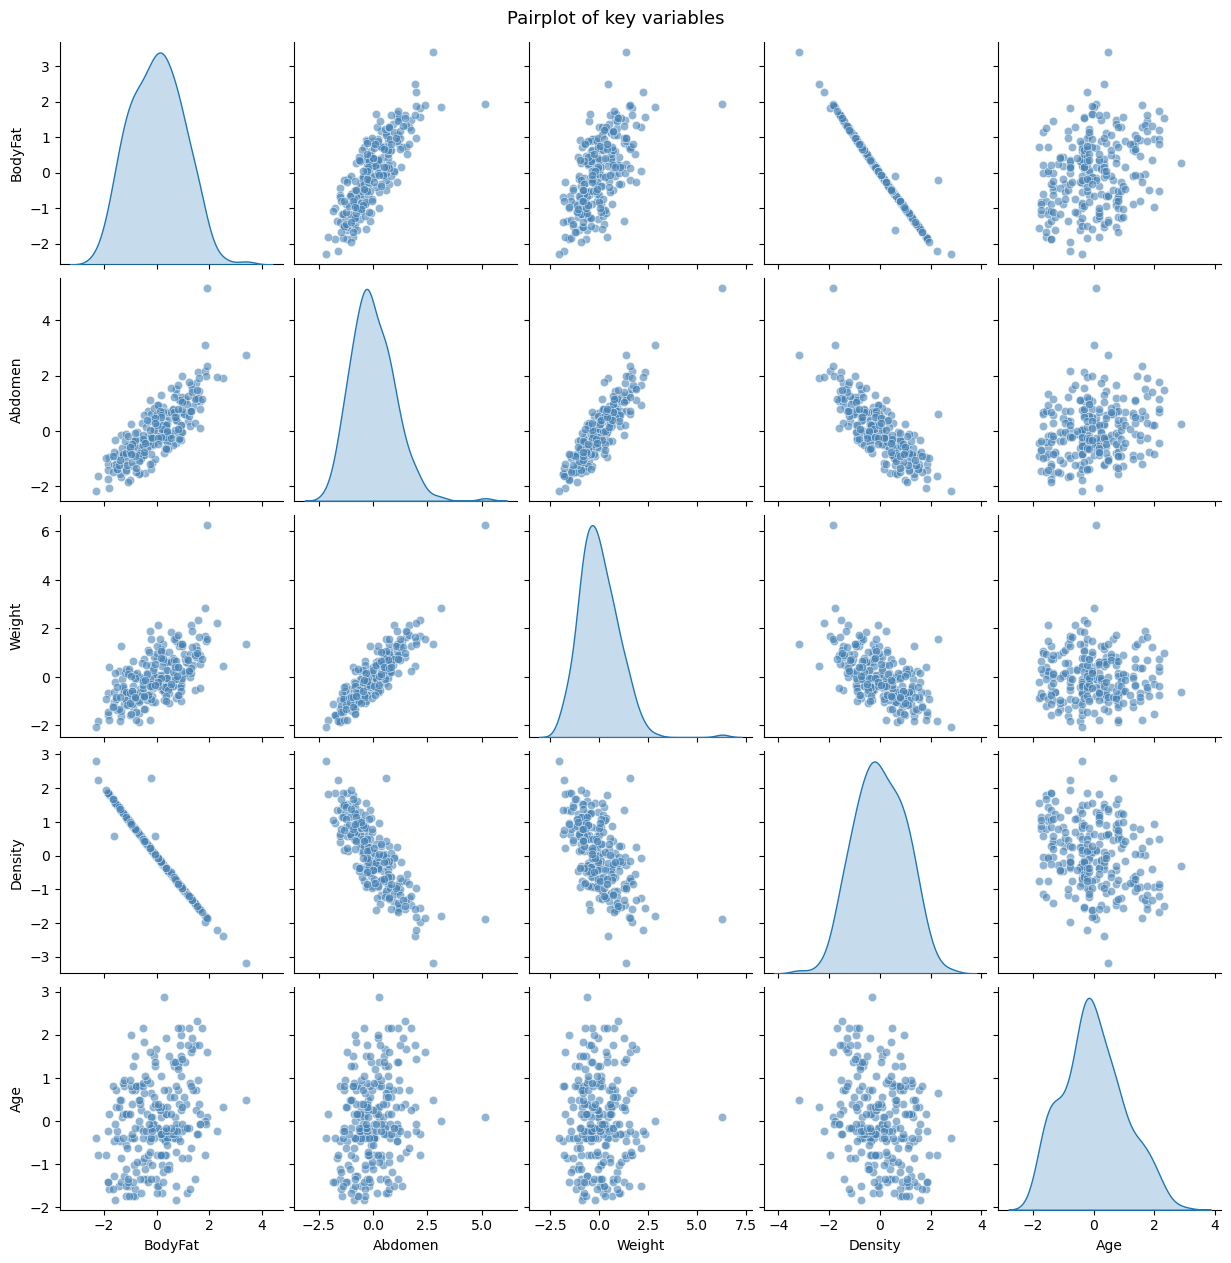

In [42]:
key_cols = ['BodyFat', 'Abdomen', 'Weight', 'Density', 'Age']
sns.pairplot(df[key_cols], diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot of key variables', y=1.01, fontsize=13)
plt.show()

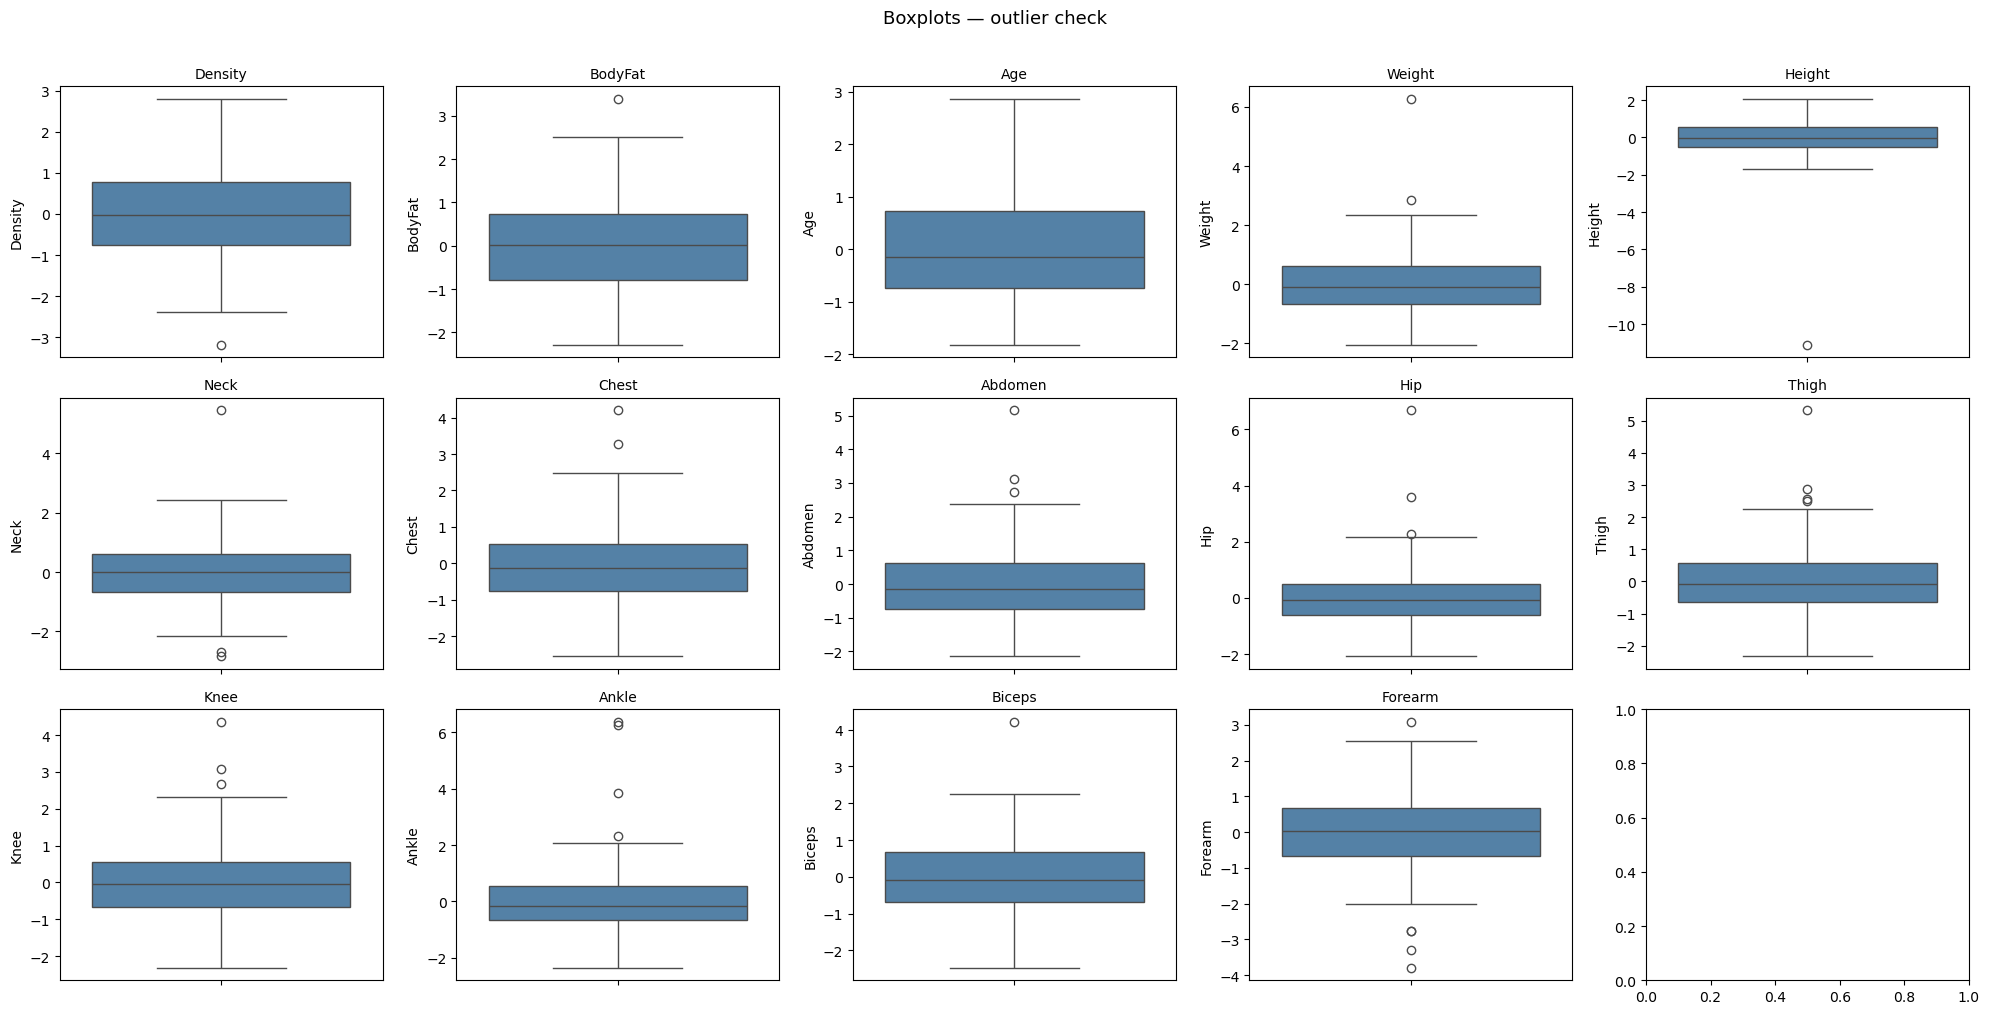

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):  # skip AgeGroup
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Boxplots — outlier check', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

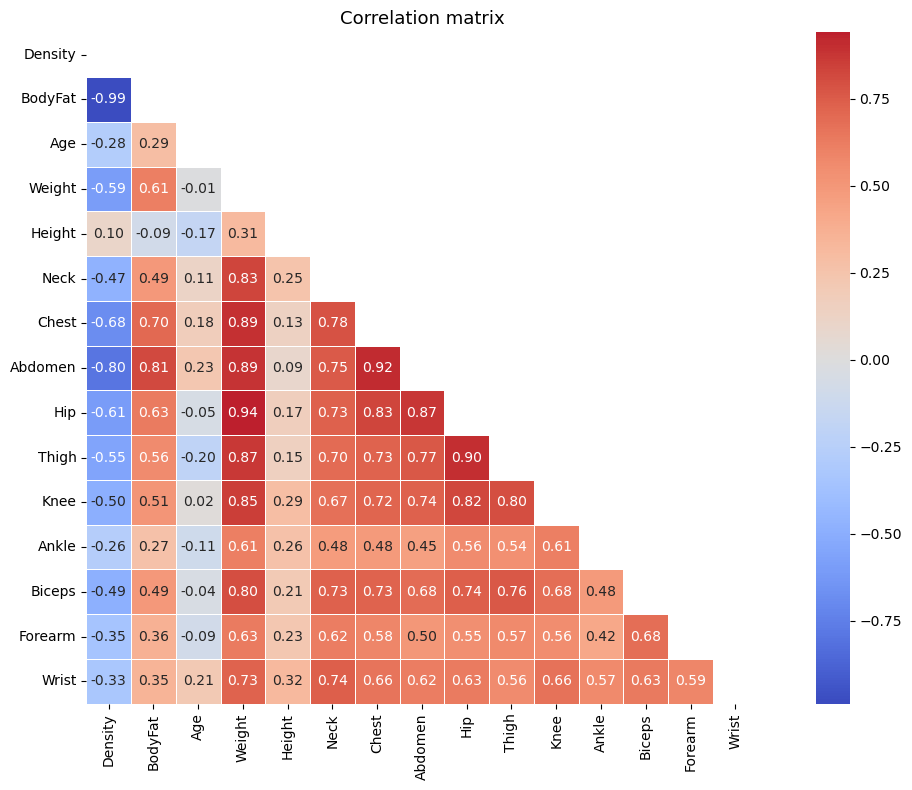

In [44]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

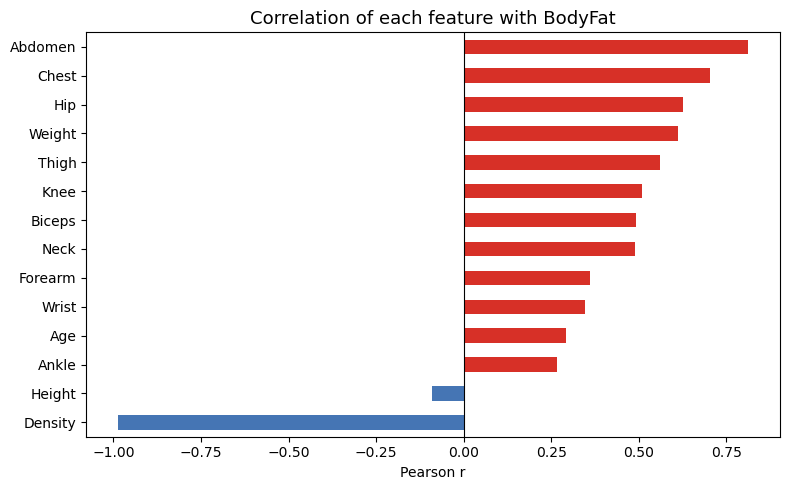

In [45]:
bodyfat_corr = corr['BodyFat'].drop('BodyFat').sort_values()

plt.figure(figsize=(8, 5))
colors = ['#d73027' if x > 0 else '#4575b4' for x in bodyfat_corr]
bodyfat_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of each feature with BodyFat', fontsize=13)
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

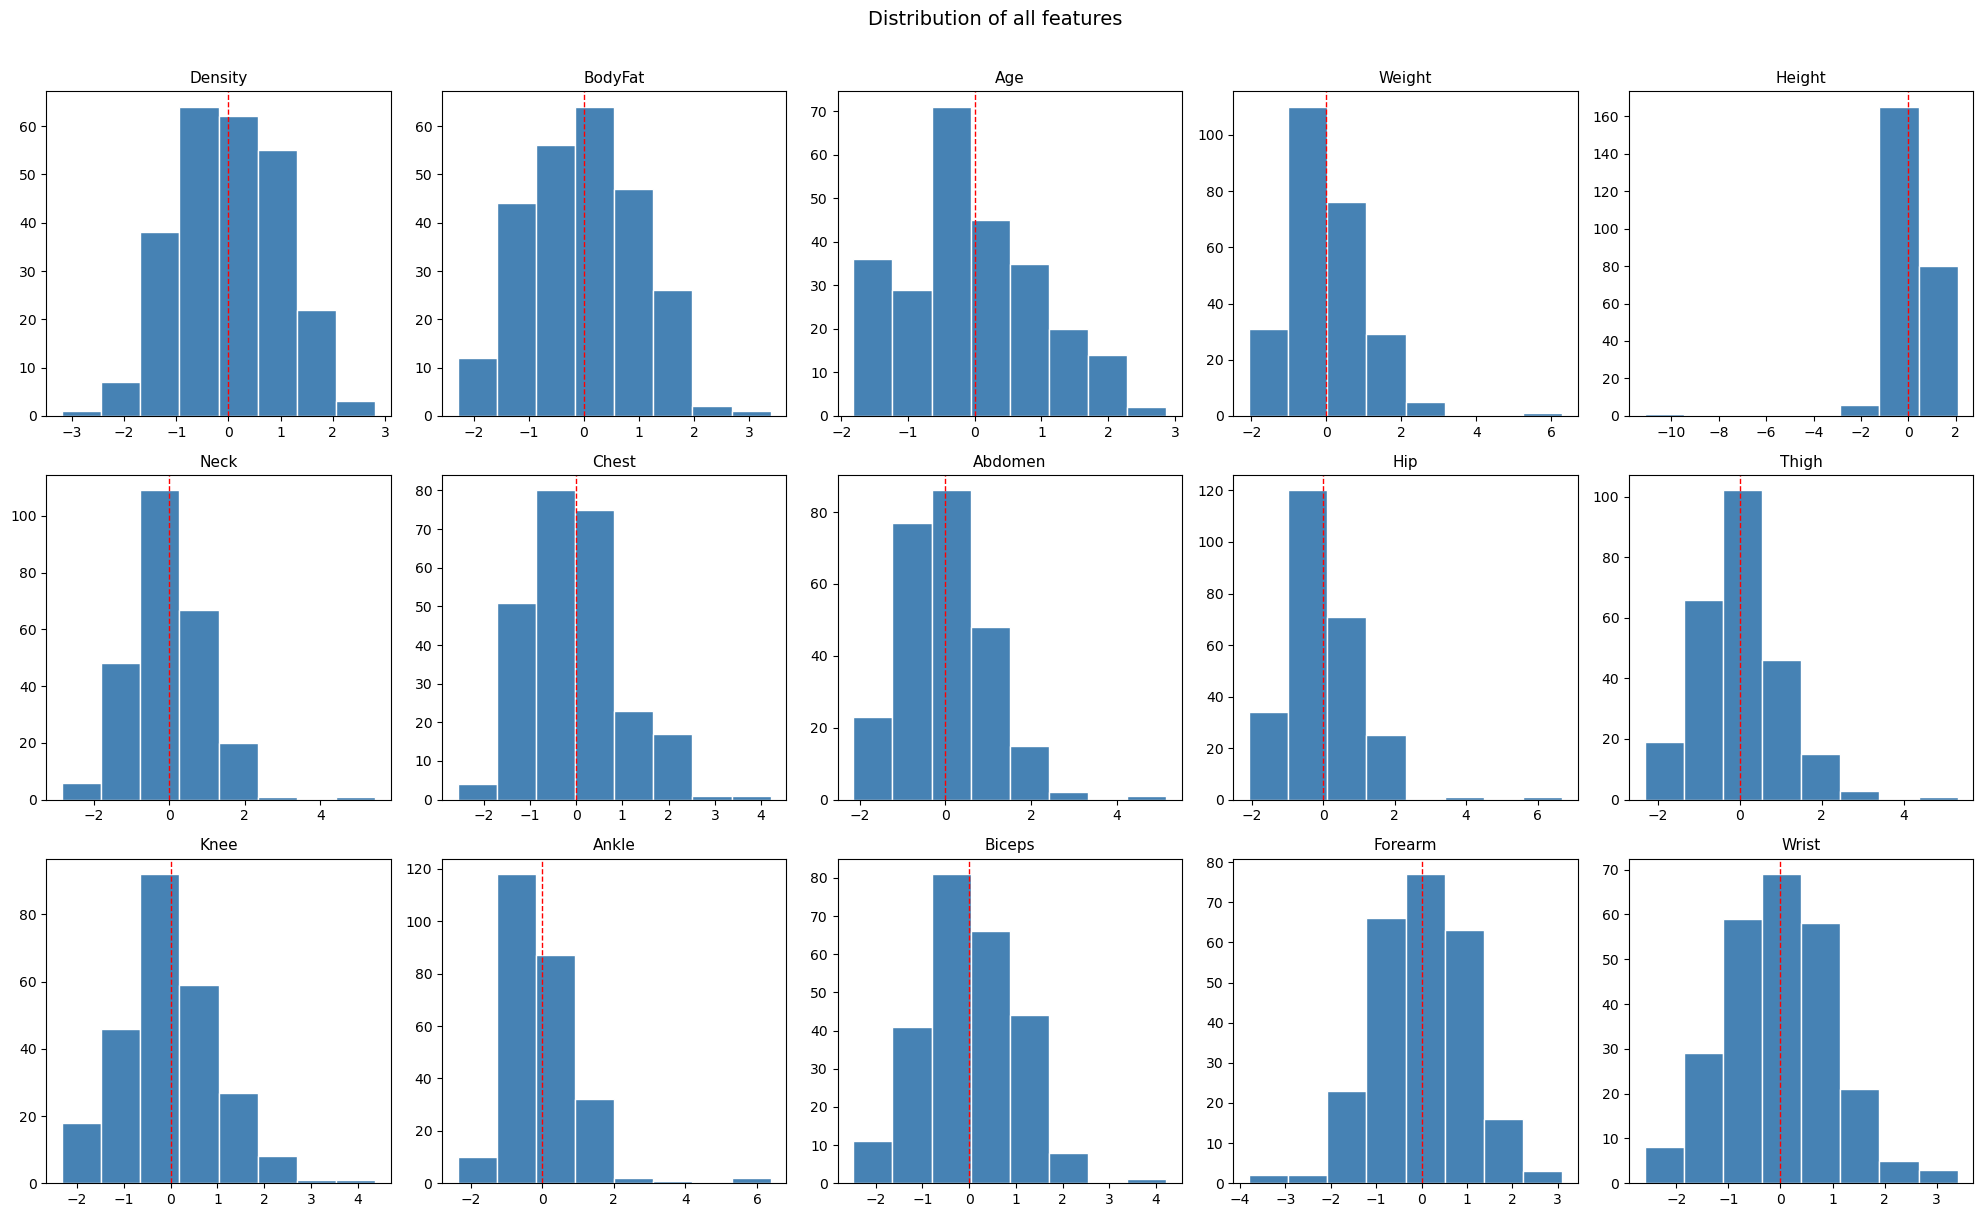

In [46]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=8, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='mean')

plt.suptitle('Distribution of all features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x= df.drop(['BodyFat'],axis=1)
y= df[['BodyFat']]

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,shuffle=True,random_state=44)

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
reg = LinearRegression()

In [52]:
reg.fit(x_train,y_train)

LinearRegression()

In [53]:
y_pred = reg.predict(x_test)

In [54]:
from sklearn.metrics import r2_score

In [55]:
print(r2_score(y_pred,y_test))

0.9747708195908196


In [56]:
from sklearn.preprocessing import PolynomialFeatures


In [57]:
poly = PolynomialFeatures(degree=2, include_bias=False)


In [58]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly= poly.transform(x_test)

In [59]:
lr = LinearRegression()

In [60]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:

x_train_poly = poly.fit_transform(x_train)  
x_test_poly  = poly.transform(x_test)       

lr = LinearRegression()
lr.fit(x_train_poly, y_train)              

y_poly_pred = lr.predict(x_test_poly)       

In [63]:
print(r2_score(y_test,y_poly_pred,))

0.9314082649129566
